In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input



In [34]:
train_path='../data/brain_tumor/Training'
test_path='../data/brain_tumor/Testing'
print("Training classes:",os.listdir(train_path))
print("Testing classes:",os.listdir(test_path))

Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [35]:
classes = ["glioma", "meningioma", "notumor", "pituitary"]
for cls in classes:
    train_count=len(os.listdir(os.path.join(train_path,cls)))
    test_count=len(os.listdir(os.path.join(test_path,cls)))
    print(cls)
    print("train",train_count)
    print("test",test_count)

glioma
train 1400
test 400
meningioma
train 1400
test 400
notumor
train 1400
test 400
pituitary
train 1400
test 400


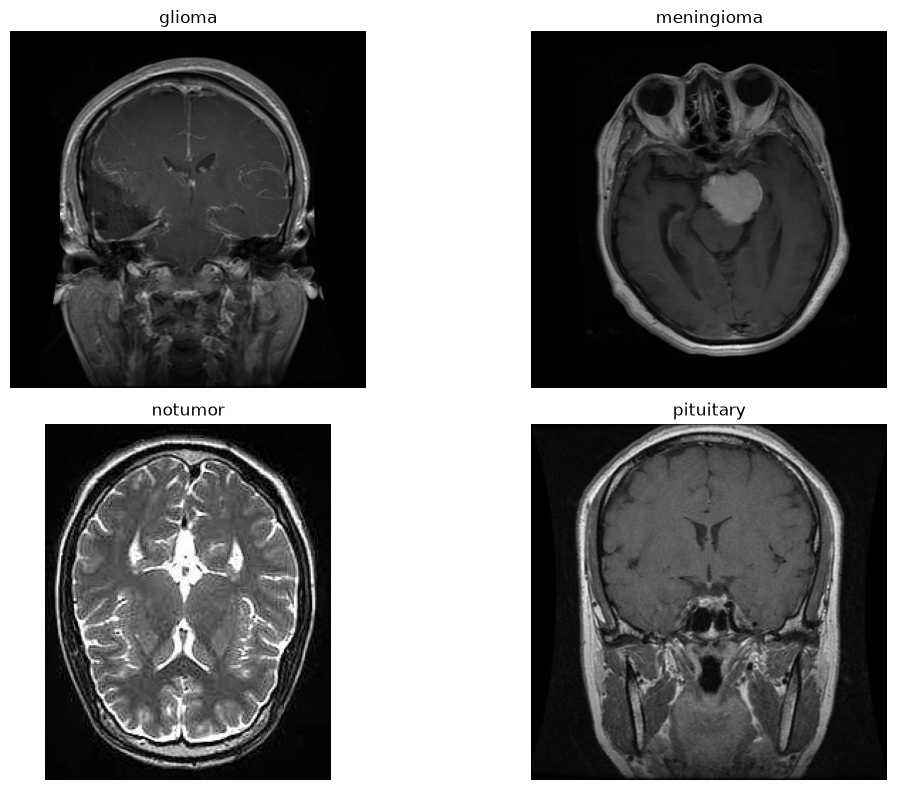

In [36]:
plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_path, cls)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    img = plt.imread(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [37]:
sample_cls=classes[0]
sample_img=os.listdir(os.path.join(train_path,sample_cls))[0]
sample_pth=os.path.join(train_path,sample_cls,sample_img)
img=plt.imread(sample_pth)
print("Image shape:",img.shape)
print("Image type:",img.dtype)
print("Minimum pixel value:",img.min())
print("Maximum pixel value:",img.max())


Image shape: (512, 512)
Image type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [38]:
print("Number of dimensions:", len(img.shape))
print("Full shape:", img.shape)

Number of dimensions: 2
Full shape: (512, 512)


DATA PREPROCESSING

In [39]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 4480 images belonging to 4 classes.


In [40]:
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

validation_set = validation_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1120 images belonging to 4 classes.


In [41]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(training_set.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=training_set.classes
)

class_weights = dict(zip(classes, class_weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0), np.int32(2): np.float64(1.0), np.int32(3): np.float64(1.0)}


In [16]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [17]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 21s 1us/step


In [18]:
base_model.trainable = False

In [19]:
model = tf.keras.models.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        4,
        activation='softmax'
    )
])

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

In [23]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.5462 - loss: 1.1081 - val_accuracy: 0.8018 - val_loss: 0.5843
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 126s 901ms/step - accuracy: 0.7504 - loss: 0.6579 - val_accuracy: 0.8438 - val_loss: 0.4752
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 130s 930ms/step - accuracy: 0.7991 - loss: 0.5524 - val_accuracy: 0.8518 - val_loss: 0.4333
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 133s 950ms/step - accuracy: 0.8219 - loss: 0.4916 - val_accuracy: 0.8732 - val_loss: 0.3839
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 130s 926ms/step - accuracy: 0.8391 - loss: 0.4513 - val_accuracy: 0.8821 - val_loss: 0.3559
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 122s 868ms/step - accuracy: 0.8551 - loss: 0.4100 - val_accuracy: 0.8723 - val_loss: 0.3546
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 114s 815ms/step - accuracy: 0.8567 - loss: 0.3927 - val_accuracy: 0.8821 - val_loss: 0.3441
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 116s 832ms/step - accuracy: 0.8551 - lo

In [24]:
test_set.reset()
test_loss,test_accuracy=model.evaluate(test_set)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 634ms/step - accuracy: 0.8431 - loss: 0.4594
Test Loss: 0.45935776829719543
Test Accuracy: 0.8431249856948853


In [25]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable=False

for layer in base_model.layers[-40:]:
    layer.trainable=True

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

In [28]:
history_finetune = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 131s 870ms/step - accuracy: 0.8362 - loss: 0.4503 - val_accuracy: 0.8866 - val_loss: 0.3042 - learning_rate: 1.0000e-05
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 118s 843ms/step - accuracy: 0.8667 - loss: 0.3519 - val_accuracy: 0.8964 - val_loss: 0.2885 - learning_rate: 1.0000e-05
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 122s 872ms/step - accuracy: 0.8737 - loss: 0.3266 - val_accuracy: 0.9000 - val_loss: 0.2679 - learning_rate: 1.0000e-05
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 129s 921ms/step - accuracy: 0.8830 - loss: 0.3097 - val_accuracy: 0.9045 - val_loss: 0.2617 - learning_rate: 1.0000e-05
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 128s 916ms/step - accuracy: 0.8913 - loss: 0.2899 - val_accuracy: 0.9054 - val_loss: 0.2547 - learning_rate: 1.0000e-05
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 128s 912ms/step - accuracy: 0.8913 - loss: 0.2938 - val_accuracy: 0.9089 - val_loss: 0.2530 - learning_rate: 1.0000e-05
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 

In [29]:
test_set.reset()

test_loss, test_accuracy = model.evaluate(test_set)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 731ms/step - accuracy: 0.8988 - loss: 0.3986
Test Loss: 0.3986305892467499
Test Accuracy: 0.8987500071525574


In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

test_set.reset()

y_true = test_set.classes
y_pred_prob = model.predict(test_set)
y_pred = np.argmax(y_pred_prob, axis=1)

class_names = list(test_set.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 619ms/step
Confusion Matrix:
[[307  59  29   5]
 [ 17 341  14  28]
 [  0   3 397   0]
 [  1   6   0 393]]

Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.77      0.85       400
  meningioma       0.83      0.85      0.84       400
     notumor       0.90      0.99      0.95       400
   pituitary       0.92      0.98      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



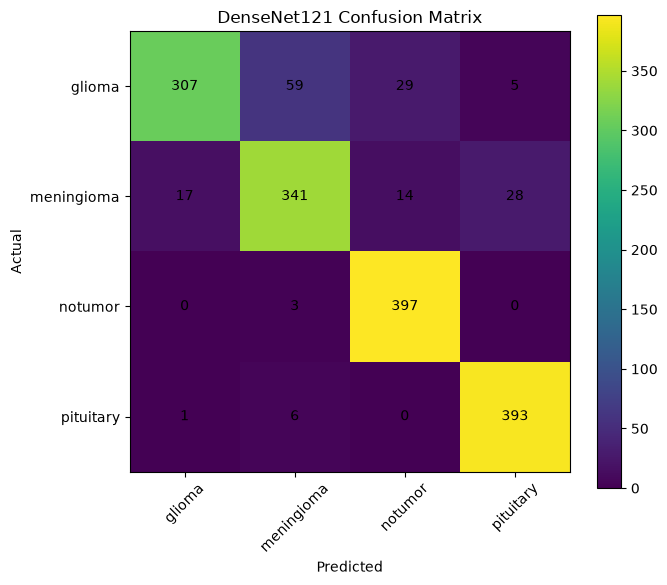

In [32]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet121 Confusion Matrix")

plt.tight_layout()
plt.show()

In [45]:
model.save(r"D:\Medical-Image-Diagnosis\models\densenet121_brain_tumor.keras")

In [49]:
from tensorflow.keras.models import load_model

model = load_model(
    r"D:\Medical-Image-Diagnosis\models\brain_tumor_densenet121.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [62]:
import random

all_images = []

for class_name in class_names:
    class_folder = os.path.join(test_path, class_name)

    for filename in os.listdir(class_folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            all_images.append((os.path.join(class_folder, filename), class_name))

random_images = random.sample(all_images, 5)

for img_path, actual_class in random_images:

    img = image.load_img(
        img_path,
        target_size=(224, 224),
        color_mode="rgb"
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    print("Image:", os.path.basename(img_path))
    print("Actual:", actual_class)
    print("Predicted:", predicted_class)
    print("Confidence:", f"{confidence * 100:.2f}%")
    
    if actual_class == predicted_class:
        print("Result:  Correct")
    else:
        print("Result:  Incorrect")
        
    print(" " * 40)

Image: Te-aug-me_47.jpg
Actual: meningioma
Predicted: meningioma
Confidence: 79.43%
Result:  Correct
                                        
Image: Te-gl_213.jpg
Actual: glioma
Predicted: pituitary
Confidence: 55.82%
Result:  Incorrect
                                        
Image: Te-pi_153.jpg
Actual: pituitary
Predicted: pituitary
Confidence: 99.45%
Result:  Correct
                                        
Image: Te-pi_276.jpg
Actual: pituitary
Predicted: pituitary
Confidence: 97.20%
Result:  Correct
                                        
Image: Te-pi_243.jpg
Actual: pituitary
Predicted: pituitary
Confidence: 99.62%
Result:  Correct
                                        
